# Phase 5: Risk Adjusted Performance

## 1. Imports

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
sys.path.append(str(project_root))

## 2. Load Daily Returns

In [2]:
data_path = project_root / "data" / "processed" / "daily_returns.csv"

daily_returns = pd.read_csv(
    data_path,
    index_col=0,
    parse_dates=True
)

daily_returns.head()

,JPM,SPY,TLT,GLD,JNJ,AAPL,XOM,KO
Date,,,,,,,,
2016-01-05,0.001729,0.001691,-0.004034,0.002819,0.004180,-0.025059,0.008520,0.003538
2016-01-06,-0.014436,-0.012614,0.013475,0.014441,-0.005055,-0.019570,-0.008320,-0.005406
2016-01-07,-0.040439,-0.023991,0.001795,0.014140,-0.011654,-0.042205,-0.016006,-0.016540
2016-01-08,-0.022399,-0.010977,0.004479,-0.004428,-0.010684,0.005288,-0.020202,-0.002643
2016-01-11,-0.001528,0.000990,-0.010944,-0.008895,-0.006010,0.016192,-0.013389,0.001686


## 3. Annual Returns

In [3]:
annual_returns = (1+daily_returns).prod() ** (252 / len(daily_returns)) - 1

annual_returns

JPM     0.206839
SPY     0.151494
TLT    -0.007847
GLD     0.131987
JNJ     0.123151
AAPL    0.282896
XOM     0.114620
KO      0.098636
dtype: float64

## 4. Annual Volatility

In [4]:
annual_volatility = daily_returns.std() * np.sqrt(252)

annual_volatility

JPM     0.274040
SPY     0.178086
TLT     0.147469
GLD     0.162449
JNJ     0.184832
AAPL    0.289163
XOM     0.279524
KO      0.181695
dtype: float64

## 5. Sharpe Ratio

In [5]:
sharpe_ratio = annual_returns / annual_volatility

sharpe_ratio

JPM     0.754775
SPY     0.850677
TLT    -0.053212
GLD     0.812481
JNJ     0.666285
AAPL    0.978327
XOM     0.410056
KO      0.542866
dtype: float64

## 6. Ranking Assets

In [6]:
sharpe_ratio.sort_values(ascending=False)

AAPL    0.978327
SPY     0.850677
GLD     0.812481
JPM     0.754775
JNJ     0.666285
KO      0.542866
XOM     0.410056
TLT    -0.053212
dtype: float64

## 7. Summary

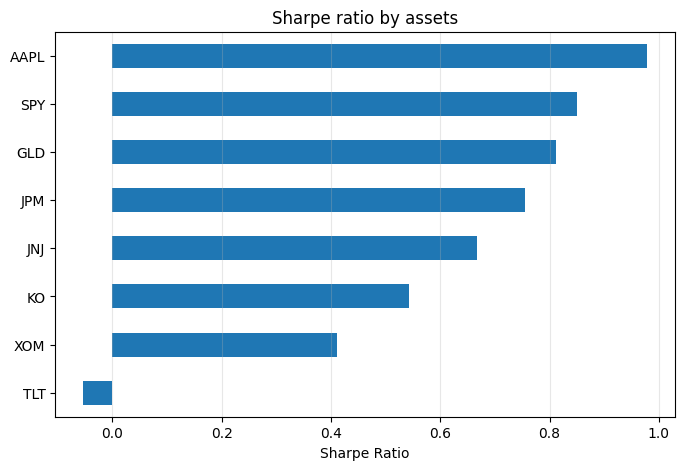

In [7]:
sharpe_ratio.sort_values().plot(
    kind="barh",
    figsize=(8,5),
    title="Sharpe ratio by assets"

)

plt.xlabel("Sharpe Ratio")
plt.grid(axis ="x", alpha=0.3)
plt.show()

In [8]:
weights = np.array([1/8]*8)
portfolio_returns = daily_returns.dot(weights)

In [9]:
portfolio_annual_return = (1+ portfolio_returns).prod() ** (252 / len(portfolio_returns)) - 1

print(f"Portfolio Annual Return: {portfolio_annual_return:.2%}")

Portfolio Annual Return: 15.34%


In [10]:
portfolio_annual_volatility = portfolio_returns.std() * np.sqrt(252)
print(f"Portfolio Annual Volatility: {portfolio_annual_volatility:.2%}")


Portfolio Annual Volatility: 12.58%


In [11]:
portfolio_sharpe = portfolio_annual_return / portfolio_annual_volatility

print(f"Portfolio Sharpe ratio: {portfolio_sharpe:.2%}")

Portfolio Sharpe ratio: 121.91%


In [12]:
comparison = sharpe_ratio.copy()
comparison["Portfolio"] = portfolio_sharpe

comparison.sort_values(ascending=False)

Portfolio    1.219116
AAPL         0.978327
SPY          0.850677
GLD          0.812481
JPM          0.754775
JNJ          0.666285
KO           0.542866
XOM          0.410056
TLT         -0.053212
dtype: float64